<a href="https://colab.research.google.com/github/Rakshakotyan/soil-fertilizer-analytics/blob/main/soil_health_and_fertilizer_recommendation_analytics_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings for a clean output
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

print("✅ Step 1: Libraries Loaded Successfully")

✅ Step 1: Libraries Loaded Successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings for a clean output
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

print("✅ Step 1: Libraries Loaded Successfully")
# Load the dataset
try:
    df = pd.read_csv('/content/fertilizer_prediction.csv')
    print("✅ Step 2: Dataset Loaded")
except FileNotFoundError:
    print("❌ Error: 'fertilizer_prediction.csv' not found. Please ensure it's uploaded to the files tab.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

# Check for missing values
print("\n--- Missing Values Check ---")
if 'df' in locals(): # Check if df was successfully created
    print(df.isnull().sum())
else:
    print("DataFrame 'df' not created due to previous error.")

# Display basic statistics
print("\n--- Statistical Summary ---")
if 'df' in locals():
    display(df.describe())
else:
    print("DataFrame 'df' not created due to previous error.")

✅ Step 1: Libraries Loaded Successfully
✅ Step 2: Dataset Loaded

--- Missing Values Check ---
Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

--- Statistical Summary ---


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,30.282828,59.151515,43.181818,18.909091,3.383838,18.606061
std,3.502304,5.840331,11.271568,11.599693,5.814667,13.476978
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,54.000000,34.000000,10.000000,0.000000,9.000000
50%,30.000000,60.000000,41.000000,13.000000,0.000000,19.000000
75%,33.000000,64.000000,50.500000,24.000000,7.500000,30.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000


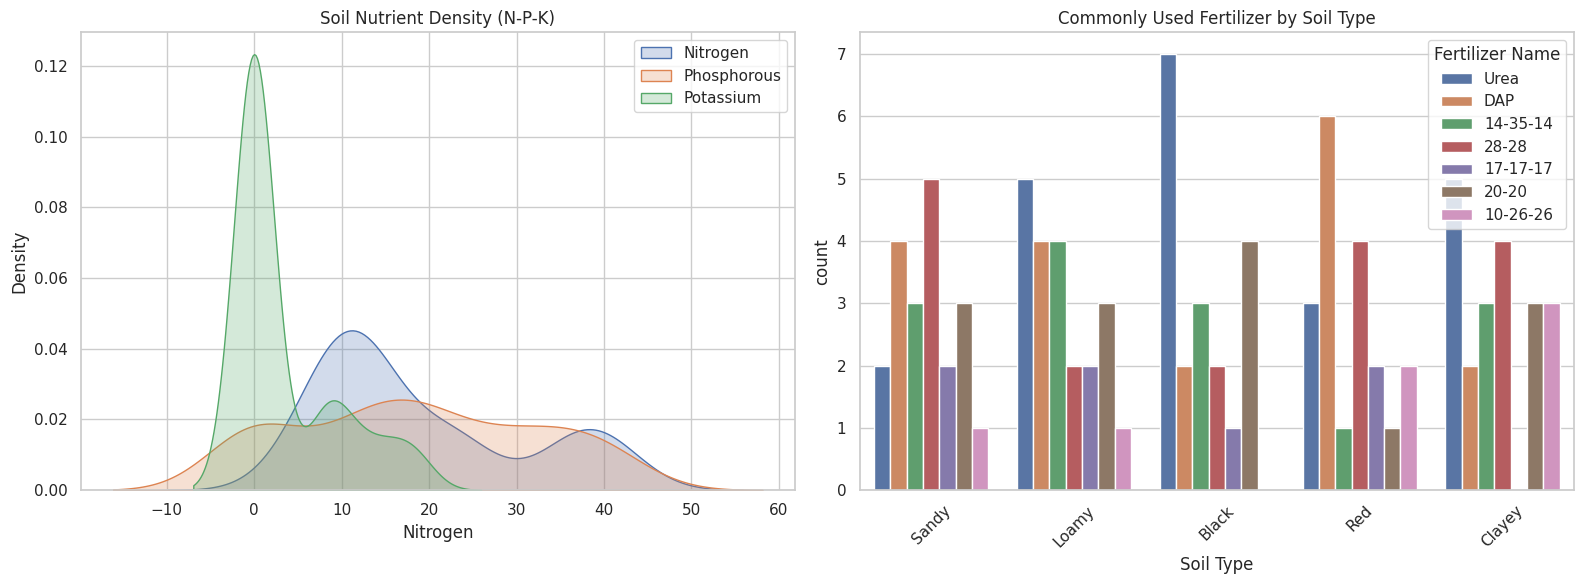

In [6]:
# Create a dashboard of 2 charts
plt.figure(figsize=(16, 6))

# Chart 1: Nutrient Distribution (N, P, K)
plt.subplot(1, 2, 1)
sns.kdeplot(df['Nitrogen'], label='Nitrogen', fill=True)
sns.kdeplot(df['Phosphorous'], label='Phosphorous', fill=True)
sns.kdeplot(df['Potassium'], label='Potassium', fill=True)
plt.title('Soil Nutrient Density (N-P-K)')
plt.legend()

# Chart 2: Soil Type vs Fertilizer Recommendation
plt.subplot(1, 2, 2)
sns.countplot(x='Soil Type', hue='Fertilizer Name', data=df)
plt.title('Commonly Used Fertilizer by Soil Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
def get_soil_advice(n, p, k):
    """Logic to suggest fertilizer based on nutrient deficiencies"""
    if n < 30:
        return "High Nitrogen (Urea)"
    elif p < 20:
        return "High Phosphorus (DAP)"
    elif k < 20:
        return "High Potassium (MOP)"
    else:
        return "Soil is Healthy! (Add Organic Compost)"

# Apply the logic to the entire dataset
df['AI_Recommendation'] = df.apply(lambda x: get_soil_advice(x['Nitrogen'], x['Phosphorous'], x['Potassium']), axis=1)

print("✅ Step 4: AI Recommendations Generated")
df[['Soil Type', 'Crop Type', 'AI_Recommendation']].head(10)

✅ Step 4: AI Recommendations Generated


,Soil Type,Crop Type,AI_Recommendation
0,Sandy,Maize,High Phosphorus (DAP)
1,Loamy,Sugarcane,High Nitrogen (Urea)
2,Black,Cotton,High Nitrogen (Urea)
3,Red,Tobacco,High Nitrogen (Urea)
4,Clayey,Paddy,High Phosphorus (DAP)
5,Sandy,Barley,High Nitrogen (Urea)
6,Red,Cotton,High Nitrogen (Urea)
7,Loamy,Wheat,High Phosphorus (DAP)
8,Sandy,Millets,High Nitrogen (Urea)
9,Black,Oil seeds,High Nitrogen (Urea)


In [8]:
print("\n--- 🪴 AI SOIL ASSISTANT: ENTER DATA ---")

try:
    user_n = float(input("Enter Nitrogen (N) value: "))
    user_p = float(input("Enter Phosphorus (P) value: "))
    user_k = float(input("Enter Potassium (K) value: "))

    result = get_soil_advice(user_n, user_p, user_k)

    print("\n" + "="*30)
    print(f"RESULTS FOR YOUR SOIL:")
    print(f"Recommendation: {result}")
    print("="*30)

except ValueError:
    print("❌ Error: Please enter numbers only.")


--- 🪴 AI SOIL ASSISTANT: ENTER DATA ---
Enter Nitrogen (N) value: 45
Enter Phosphorus (P) value: 85
Enter Potassium (K) value: 75

RESULTS FOR YOUR SOIL:
Recommendation: Soil is Healthy! (Add Organic Compost)
